# Comparison between AIMD (#55) and DPMD

In [29]:
steps = []
temp = []
totE = []
potE = []
kinE = []
with open('e.dat', 'r') as file:
    for line in file:
        line = line.strip()
        parts = line.split()
        steps.append(float(parts[0])/2)
        temp.append(float(parts[1]))
        totE.append(float(parts[2]))
        potE.append(float(parts[3]))
        kinE.append(float(parts[4]))
steps = [i/10 for i in steps]

Text(0, 0.5, 'Potential Energy (eV)')

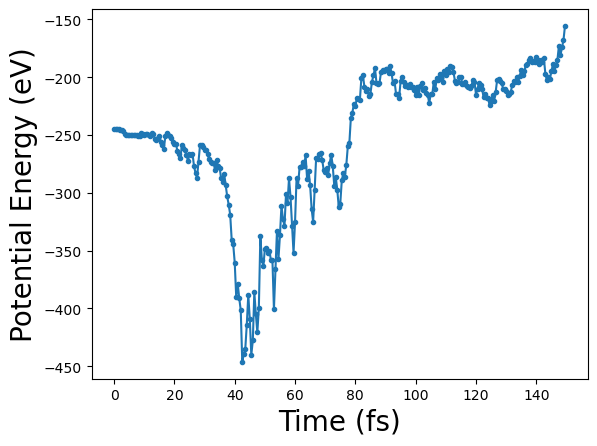

In [37]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(steps[:300],potE[:300], marker='o',markersize=3)
plt.xlabel('Time (fs)', fontsize=20)
# plt.xlim(0,175)
plt.ylabel('Potential Energy (eV)', fontsize=20)

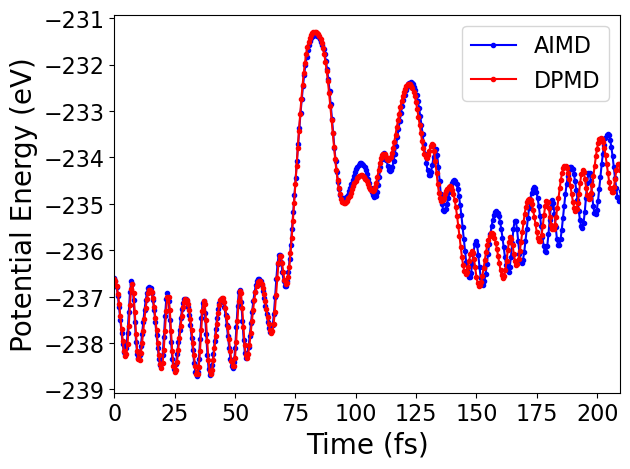

In [6]:
import re
import numpy as np
import matplotlib.pyplot as plt
pattern = (
    r'\s*(\d+)\s+'                 # step
    r'T=\s*([-\d\.E+]+)\s+'        # T
    r'E=\s*([-\d\.E+]+)\s+'        # E
    r'F=\s*([-\d\.E+]+)\s+'        # F
    r'E0=\s*([-\d\.E+]+)\s+'       # E0
    r'EK=\s*([-\d\.E+]+)\s+'       # EK
    r'SP=\s*([-\d\.E+]+)\s+'       # SP
    r'SK=\s*([-\d\.E+]+)'          # SK
)
E0s = []
# TotE = []
TS = np.linspace(0, 250, 500)

with open('OSZICAR', 'r') as file:
    for line in file:
        match = re.match(pattern, line)
        if match:
            # step = int(match.group(1))
            # T = float(match.group(2))
            # E = float(match.group(3))
            # TotE.append(E)
            # F = float(match.group(4))
            E0 = float(match.group(5))
            E0s.append(E0)
            # EK = float(match.group(6))
            # E0s.append(EK)

            # SP = float(match.group(7))
            # SK = float(match.group(8))

plt.figure()

plt.plot(TS[:420], E0s[:420], marker='o',markersize=3,label='AIMD',color='blue')
plt.plot(steps[:420],potE[:420], marker='o',markersize=3,label='DPMD',color='red')
# plt.xlabel('Time (fs)', fontsize=20)
# plt.xlim(0,500)
# plt.ylabel('Potential Energy (eV)', fontsize=20)
# plt.plot(TS, TotE, marker='o',markersize=3)
plt.xlabel('Time (fs)', fontsize=20)
plt.xlim(0,steps[:420][-1])
plt.ylabel('Potential Energy (eV)', fontsize=20)
# plt.ylim(-240,-225)
# plt.title('Potential Energies Over Time', fontsize=17)
# plt.title('Bouncing Back (5th)\n Time vs. Potential Energy\n Time step = 0.5 fs', fontsize=15)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.legend(fontsize=16)
plt.show()

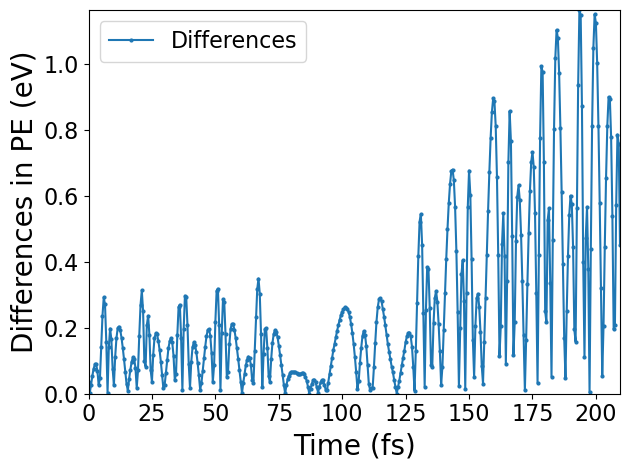

In [7]:
# plt.plot(TS, E0s, marker='o',markersize=3,label='AIMD',color='blue')
# plt.plot(steps[:420],potE[:420], marker='o',markersize=3,label='DPMD',color='red')
diff = [abs(i-j) for i, j in zip(E0s,potE[:420])]
plt.figure()
plt.plot(steps[:420], diff,marker='o',label='Differences',markersize=2)
# plt.title('PE Differences between AIMD and DPMD', fontsize = 20)
plt.ylabel('Differences in PE (eV)',fontsize=20)
plt.xlabel('Time (fs)',fontsize=20)
plt.xlim(0, steps[:420][-1])
plt.ylim(0, max(diff))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.legend(fontsize=16)
plt.show()

# Check bond length change during dynamics at different quatum state

## quantum state = 0 (ZPE)

Text(0.5, 0, 'Time (fs)')

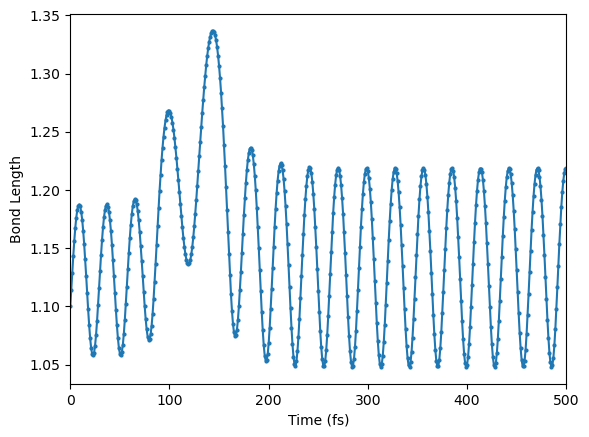

In [8]:
import numpy as np
with open('0.xyz', 'r') as file:
    lines = file.readlines()

# Extract atomic positions starting from line 8
positions = []
for line in lines:
    if line.startswith("46 N"):
        i = lines.index(line)
        p1 = np.array([float(lines[i].split()[2]),float(lines[i].split()[3]),float(lines[i].split()[4])])
    # if line.startswith('47 N'):
    #     j = lines.index(line)
        p2 = np.array([float(lines[i+1].split()[2]),float(lines[i+1].split()[3]),float(lines[i+1].split()[4])])
        positions.append((p1,p2))
    # bond_length = np.linalg.norm(position1 - position2)
bond_lengths = []
for p1, p2 in positions:
    bond_length = np.linalg.norm(p1 - p2)
    bond_lengths.append(bond_length)   
time = list(np.arange(0, len(bond_lengths), 1))

plt.figure()
plt.plot(time, bond_lengths, marker='o', markersize=2)
plt.xlim(min(time),max(time))
plt.ylabel('Bond Length')
plt.xlabel('Time (fs)')

## quantum state = 1

Text(0.5, 0, 'Time (fs)')

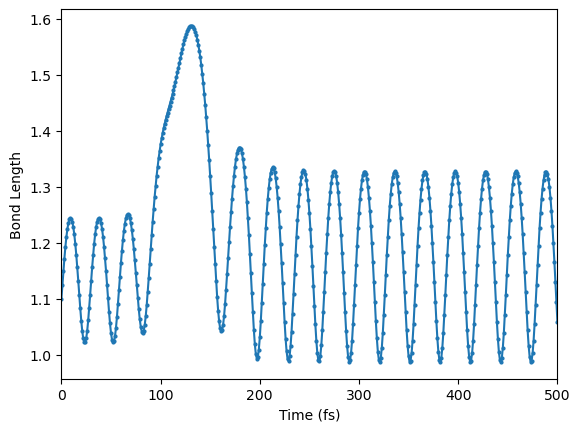

In [9]:
with open('11.xyz', 'r') as file:
    lines = file.readlines()

# Extract atomic positions starting from line 8
positions = []
for line in lines:
    if line.startswith("46 N"):
        i = lines.index(line)
        p1 = np.array([float(lines[i].split()[2]),float(lines[i].split()[3]),float(lines[i].split()[4])])
    # if line.startswith('47 N'):
    #     j = lines.index(line)
        p2 = np.array([float(lines[i+1].split()[2]),float(lines[i+1].split()[3]),float(lines[i+1].split()[4])])
        positions.append((p1,p2))
    # bond_length = np.linalg.norm(position1 - position2)
bond_lengths = []
for p1, p2 in positions:
    bond_length = np.linalg.norm(p1 - p2)
    bond_lengths.append(bond_length)   
time = list(np.arange(0, len(bond_lengths), 1))

plt.figure()
plt.plot(time, bond_lengths, marker='o', markersize=2)
plt.xlim(min(time),max(time))
plt.ylabel('Bond Length')
plt.xlabel('Time (fs)')

## quantum state = 2

Text(0.5, 0, 'Time (fs)')

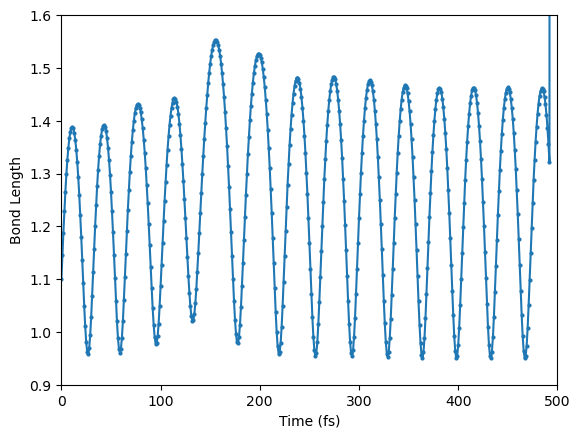

In [10]:
with open('2.xyz', 'r') as file:
    lines = file.readlines()

# Extract atomic positions starting from line 8
positions = []
for line in lines:
    if line.startswith("46 N"):
        i = lines.index(line)
        p1 = np.array([float(lines[i].split()[2]),float(lines[i].split()[3]),float(lines[i].split()[4])])
    # if line.startswith('47 N'):
    #     j = lines.index(line)
        p2 = np.array([float(lines[i+1].split()[2]),float(lines[i+1].split()[3]),float(lines[i+1].split()[4])])
        positions.append((p1,p2))
    # bond_length = np.linalg.norm(position1 - position2)
bond_lengths = []
for p1, p2 in positions:
    bond_length = np.linalg.norm(p1 - p2)
    bond_lengths.append(bond_length)   
time = list(np.arange(0, len(bond_lengths), 1))

plt.figure()
plt.plot(time, bond_lengths, marker='o', markersize=2)
plt.xlim(min(time),max(time))
plt.ylabel('Bond Length')
plt.ylim(0.9,1.6)
plt.xlabel('Time (fs)')

## quantum state = 3

In [11]:
with open('3.xyz', 'r') as file:
    lines = file.readlines()

# Extract atomic positions starting from line 8
positions = []
for line in lines:
    if line.startswith("46 N"):
        i = lines.index(line)
        p1 = np.array([float(lines[i].split()[2]),float(lines[i].split()[3]),float(lines[i].split()[4])])
    # if line.startswith('47 N'):
    #     j = lines.index(line)
        p2 = np.array([float(lines[i+1].split()[2]),float(lines[i+1].split()[3]),float(lines[i+1].split()[4])])
        positions.append((p1,p2))
    # bond_length = np.linalg.norm(position1 - position2)
bond_lengths = []
for p1, p2 in positions:
    bond_length = np.linalg.norm(p1 - p2)
    bond_lengths.append(bond_length)   
time = list(np.arange(0, len(bond_lengths), 1))

plt.figure()
plt.plot(time, bond_lengths, marker='o', markersize=2)
plt.xlim(min(time),max(time))
plt.ylabel('Bond Length')
plt.xlabel('Time (fs)')

FileNotFoundError: [Errno 2] No such file or directory: '3.xyz'

## quantum state = 4

In [12]:
with open('4.xyz', 'r') as file:
    lines = file.readlines()

# Extract atomic positions starting from line 8
positions = []
for line in lines:
    if line.startswith("46 N"):
        i = lines.index(line)
        p1 = np.array([float(lines[i].split()[2]),float(lines[i].split()[3]),float(lines[i].split()[4])])
    # if line.startswith('47 N'):
    #     j = lines.index(line)
        p2 = np.array([float(lines[i+1].split()[2]),float(lines[i+1].split()[3]),float(lines[i+1].split()[4])])
        positions.append((p1,p2))
    # bond_length = np.linalg.norm(position1 - position2)
bond_lengths = []
for p1, p2 in positions:
    bond_length = np.linalg.norm(p1 - p2)
    bond_lengths.append(bond_length)   
time = list(np.arange(0, len(bond_lengths), 1))

plt.figure()
plt.plot(time, bond_lengths, marker='o', markersize=2)
plt.xlim(min(time),max(time))
plt.ylabel('Bond Length')
plt.xlabel('Time (fs)')

FileNotFoundError: [Errno 2] No such file or directory: '4.xyz'

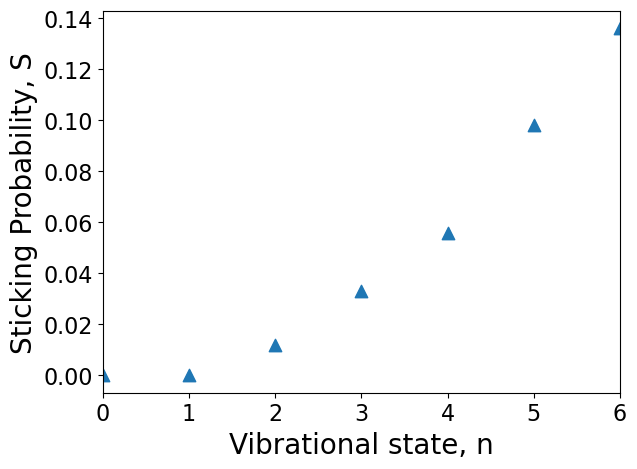

In [28]:

quatum = [0,1,2,3,4,5,6]
prob = [0.000, 0.0002, 0.012, 0.033, 0.056,0.098,0.136]
fig, ax = plt.subplots()
ax.scatter(quatum, prob,marker='^',s=80)
# plt.title('Sticking Probability vs. Vibrational State', fontsize=17)
plt.ylabel('Sticking Probability, S', fontsize=20)
plt.xlabel('Vibrational state, n', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.xlim(0,6)
ax.set_xticks(np.arange(0, 7, 1))
ax.minorticks_off()